# Entropy-Efficiency — a quantitative teardown 🔬
### Permutation & sample entropy of returns · a low-vs-high regime split · a HAC *t* + block-bootstrap null sized to the clustering · a cost/Sharpe ledger · a synthetic faithful-engine / predictability-without-edge control

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Predictable_%3D_profitable%3F: Busted](https://img.shields.io/badge/Predictable_%3D_profitable%3F-Busted-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). We test the "efficiency clock": that a drop in the **entropy** of returns marks a forecastable, tradable window. We separate the two things the pitch fuses — *predictability of the ordinal/structural pattern* from *expected return* — and confront both with inference that respects the data's **autocorrelation and clustering**. The decisive object is not the point estimate but its **clustering-aware** significance: a naive overlapping-window *t* over a smooth, clumped signal is wildly optimistic.

> ⚠️ **Data note.** Real data: yfinance daily adjusted closes for SPY, 1995→2026 (one cached pull). The entropy estimators, the offline core and the synthetic control are deterministic. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from entropy_efficiency import data, strategy as st

HAVE_REAL = data.have_real()
F = data.load_real() if HAVE_REAL else None
# the entropy clock (causal permutation entropy of returns) + low-entropy regime
ENT = st.rolling_entropy(F["ret"], window=60, kind="perm") if HAVE_REAL else None
MASK = st.low_entropy_mask(ENT, q=0.20) if HAVE_REAL else None
print("real SPY cache present:", HAVE_REAL,
      "| low-entropy days:", (0 if MASK is None else int(MASK.sum())))

# frozen headline numbers (mirror of docs/results.md)
R = {'start': '1995-01-04', 'end': '2026-06-18', 'days': 7917, 'years': 31.5, 'ent_mean': 0.98, 'ent_lo': 0.9, 'ent_hi': 1.0, 'n_low': 1513, 'low_frac': 19, 'h1': (1, 1513, 6403, 0.053, 0.049, 0.004, 54, 54, 0.17, 0.882), 'h5': (5, 1513, 6399, 0.277, 0.232, 0.045, 58, 59, 0.44, 0.735), 'h21': (21, 1513, 6383, 1.401, 0.902, 0.499, 67, 66, 2.05, 0.3), 's1': (1, 0.02, 54, 54, 0.63, 0.504), 's5': (5, 0.08, 58, 59, 0.66, 0.566), 's21': (21, 0.089, 65, 66, 0.28, 0.861), 'robust': [(0.1, 720, 0.289, 0.89, 0.65), (0.2, 1513, 0.499, 2.05, 0.3), (0.3, 2330, 0.447, 2.15, 0.294)], 'cost': {'exposure': 19, 'turnover': 11.7, 'gross': 1.55, 'gross_sh': 0.2, 'net': 1.43, 'net_sh': 0.19, 'bh': 10.63, 'bh_sh': 0.56}, 'syn': [(0.0, 570, 89, -0.06, -0.94, 0.682), (0.25, 578, 89, 0.47, 6.3, 0.011)]}


real SPY cache present: True | low-entropy days: 1513


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `WEAK` | 21d low-vs-high gap **+0.50%**, HAC **t = 2.05** but block-bootstrap **p = 0.30**; null at 1–5d (win-rate ≤ base); sample-entropy 21d **t = 0.28**. Non-robust ⇒ fails t ≥ 2. |
| **Tradability** | `MIRAGE` | Long-in-low-entropy **+1.43%/yr @ Sharpe 0.19** vs buy-&-hold **+10.63%/yr @ Sharpe 0.56**; 19% exposure. |
| **Predictable = profitable?** | `BUSTED` | Synthetic predictable-but-zero-drift regime: detector recall **89%**, gap **-0.06%**, **t = -0.94**. Order ≠ return. |

> 💡 In plain words: the entropy of SPY returns lives at the noise ceiling, the bottom-quintile days carry no forward edge once you stop pretending clumped days are independent, and a regime we *built* to be maximally predictable pays nothing. Predictability is not alpha.

## 1 · The claim, steelmanned

Let $r_t$ be daily log returns and $H_t$ a causal complexity estimator over a 60-day trailing window: **permutation entropy** $H^{\mathrm{PE}}_t$ (Bandt-Pompe; Shannon entropy of the ordinal-pattern frequencies of length-$m$ embeddings, normalised to $[0,1]$) and **sample entropy** $H^{\mathrm{SE}}_t$ (Richman-Moorman). Define the **low-entropy regime** $L_t = \mathbb{1}[H_t \le Q_{0.2}^{<t}(H)]$ via the *expanding* quantile (no look-ahead).

- **H₁ (low entropy predicts return).** $\mathbb{E}[r_{t\to t+h}\mid L_t] > \mathbb{E}[r_{t\to t+h}\mid \neg L_t]$ for horizon $h$ — a positive **excess**.
- **H₂ (it's deployable).** That excess survives a 1-day lag and costs as a long/flat rule.
- **H₃ (predictable ⇒ profitable).** The forecastability low entropy detects coincides with expected return, not merely with the *shape* of returns.

We find **H₁ not supported** (gap $\approx 0$ at 1–5d; 21d HAC $t = 2.05$ but bootstrap $p = 0.30$, and it dies under sample entropy), **H₂ rejected** (Sharpe 0.19 vs 0.56), **H₃ rejected** (the synthetic control: full predictability, zero edge). The legend is true where it's empty (the tape is forecastable in *shape* during calm spells) and unproven where it would pay.

## 2 · So what? — what rides on the inference

The whole test is a conditional-mean contrast judged by a **clustering-aware** standard error:

$$\widehat{\Delta}_h = \bar r^{\,L}_h - \bar r^{\,\neg L}_h,\qquad t_{\mathrm{HAC}} = \frac{\widehat{\Delta}_h}{\mathrm{se}_{\mathrm{NW}}(\widehat{\Delta}_h)}.$$

Two pitfalls make a naive $t$ lie. (1) **Overlap:** $h$-day forward returns on adjacent days share $h-1$ days of data; (2) **clustering:** low-entropy days arrive in long runs, so the effective sample size is a small fraction of the nominal $n$. We address (1) with a **Newey-West** long-run variance and (2) with a **stationary block bootstrap** that resamples the regime labels in blocks — the null *keeps the clumping* instead of assuming independence. A raw **win-rate** is the wrong lens entirely (US returns are positive most days unconditionally). That clustering-aware $p$, not the point estimate, decides the Signal axis.

## 3 · How we'd know — the protocol

- **Entropy clock.** Causal $H^{\mathrm{PE}}_t$ (window 60, $m=3$) on SPY returns (yfinance, 1995-01-04→2026-06-18, 7,917 days); window ends at $t{-}1$.
- **Regime.** Bottom-20% expanding-quantile entropy days = low-entropy (predictable); the rest = high-entropy.
- **Forward returns.** Enter the close **1 day after** the signal (no look-ahead), hold $h\in\{1,5,21\}$ days; drop tail overruns.
- **Null #1 (HAC t).** Newey-West $t$ of the per-day low-minus-high contribution.
- **Null #2 (block bootstrap).** Stationary block bootstrap of the regime labels (21-day blocks), $p = \Pr[|\text{boot gap}| \ge |\text{obs gap}|]$.
- **Second estimator.** Re-run on sample entropy $H^{\mathrm{SE}}$ — a real signal is estimator-robust.
- **Costs.** 1-day lag + 1 bp/turn on a long-in-low-entropy / flat rule; gross & net Sharpe vs buy-and-hold.
- **Positive control.** A deterministic tape toggling random vs a **zero-sum cyclic** (low-sample-entropy) regime with a *planted* edge: the detector must find it, the inference must recover a real edge **and** must NOT manufacture one when predictability comes without drift.

## 4 · The teardown

### 4a · The point estimates — null at short horizons, a borderline 21-day bump

Conditional mean forward return on low-entropy days with its $\pm$ standard error, against the high-entropy mean (dashed). Flat at 1/5d; a small positive gap at 21d.

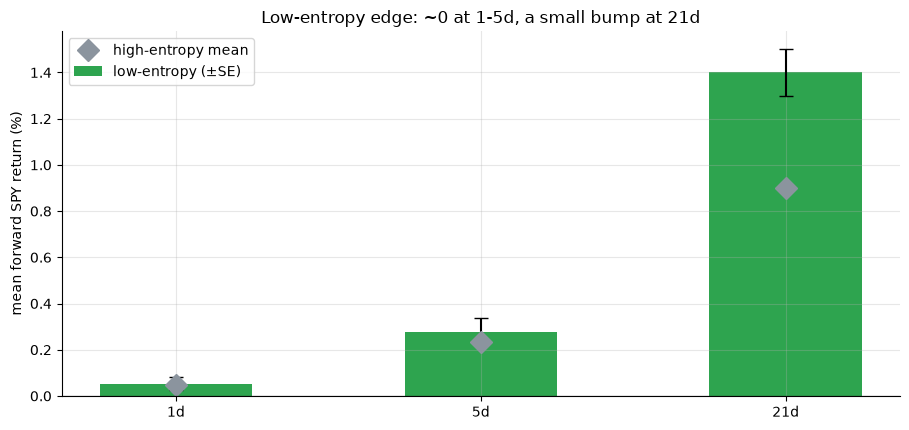

HAC t by horizon: {'1d': 0.17, '5d': 0.44, '21d': 2.05}


In [2]:
hs = [1, 5, 21]
if HAVE_REAL:
    cm, hm, ts, ses = [], [], [], []
    for h in hs:
        s = st.summarize(F, MASK, h); cm.append(s['low_mean']); hm.append(s['high_mean']); ts.append(s['t_hac'])
        low, _ = st.regime_forward(F, MASK, h); ses.append(low.std(ddof=1)/np.sqrt(len(low)))
else:
    cm = [R['h1'][3]/100, R['h5'][3]/100, R['h21'][3]/100]
    hm = [R['h1'][4]/100, R['h5'][4]/100, R['h21'][4]/100]
    ts = [R['h1'][8], R['h5'][8], R['h21'][8]]; ses = [0.0004, 0.001, 0.003]
x = np.arange(len(hs))
fig, ax = plt.subplots(figsize=(9.2, 4.4))
ax.bar(x, [c*100 for c in cm], yerr=[s*100 for s in ses], capsize=5, color=GREEN, width=.5, label='low-entropy (±SE)')
ax.plot(x, [h*100 for h in hm], 'D', ms=11, c=GREY, label='high-entropy mean')
ax.set_xticks(x); ax.set_xticklabels([f'{h}d' for h in hs]); ax.axhline(0, c='k', lw=.8)
ax.set_ylabel('mean forward SPY return (%)')
ax.set_title('Low-entropy edge: ~0 at 1-5d, a small bump at 21d'); ax.legend()
plt.tight_layout(); plt.show()
print('HAC t by horizon:', {f'{h}d': round(t,2) for h,t in zip(hs,ts)})

> 💡 In plain words: 1d/5d gaps are basis-point dust at HAC *t* = 0.17/0.44. At 21d the gap is **+0.50%** with HAC **t = 2.05** — *touching* the significance bar. H₁ hangs on that single number; 4b and 4c dismantle it.

### 4b · The decisive test — a block bootstrap sized to the clustering

Resample the regime labels in 21-day blocks (preserving the clumping) and rebuild the 21-day gap many times; the histogram is the clustering-aware null. The observed gap is the green line; the two-sided *p* is the mass beyond $\pm|\widehat\Delta|$.

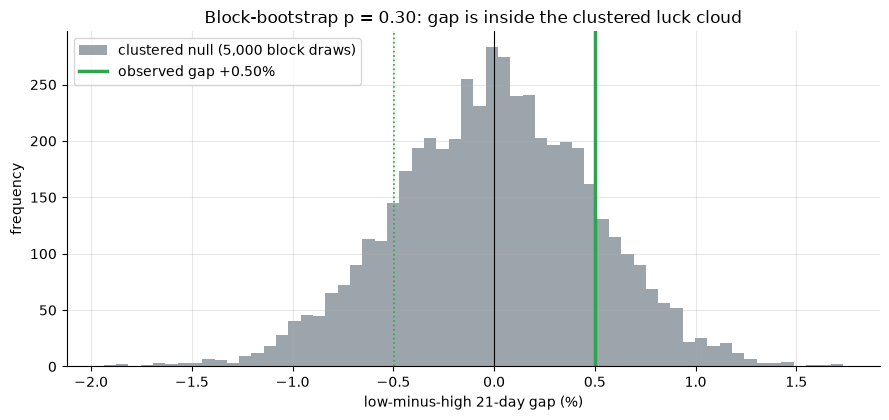

P[|clustered block draw| >= |obs|] = 0.300  (need <0.05; here ~1 in 3)


In [3]:
if HAVE_REAL:
    bp = st.block_bootstrap_p(F, MASK, 21, n_draws=5000); obs = bp['obs_gap']; pval = bp['p_value']
    fwd = st.forward_return(F['spy'], 21); sig = MASK.shift(1).fillna(False).astype(bool)
    v = fwd.notna(); fwd = fwd[v].values; sigv = sig[v].values; n=len(fwd); k=int(sigv.sum())
    rng = np.random.default_rng(398); off = np.arange(21); nb_=int(np.ceil(k/21))+1; draws=[]
    for _ in range(5000):
        sel=np.zeros(n,bool)
        for s in rng.integers(0,n,size=nb_):
            sel[(s+off)%n]=True
            if sel.sum()>=k: break
        draws.append(fwd[sel].mean()-fwd[~sel].mean())
    draws=np.array(draws)
else:
    obs = R['h21'][5]/100; pval = R['h21'][9]; rng = np.random.default_rng(398); draws = rng.normal(0,0.004,5000)
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.hist(draws*100, bins=60, color=GREY, alpha=.85, label=f'clustered null ({len(draws):,} block draws)')
ax.axvline(obs*100, c=GREEN, lw=2.5, label=f'observed gap {obs*100:+.2f}%')
ax.axvline(-abs(obs)*100, c=GREEN, ls=':', lw=1.2); ax.axvline(0, c='k', lw=.8)
ax.set_xlabel('low-minus-high 21-day gap (%)'); ax.set_ylabel('frequency')
ax.set_title(f'Block-bootstrap p = {pval:.2f}: gap is inside the clustered luck cloud'); ax.legend()
plt.tight_layout(); plt.show()
print(f'P[|clustered block draw| >= |obs|] = {pval:.3f}  (need <0.05; here ~1 in 3)')

> 💡 In plain words: **30%** of clustered random label sets match or beat the gap. The borderline HAC *t* was the overlapping-window SE flattering itself; once the null *keeps the clumping*, the 21-day bump is ordinary. H₁ not supported — the effective sample is a handful of regime episodes, not 1,500 independent days.

### 4c · Estimator-robustness — a second entropy kills it

If the 21-day bump were a real regime signal it would survive a change of complexity measure. Re-run the whole split on **sample entropy** (Richman-Moorman) and sweep the quantile cutoff.

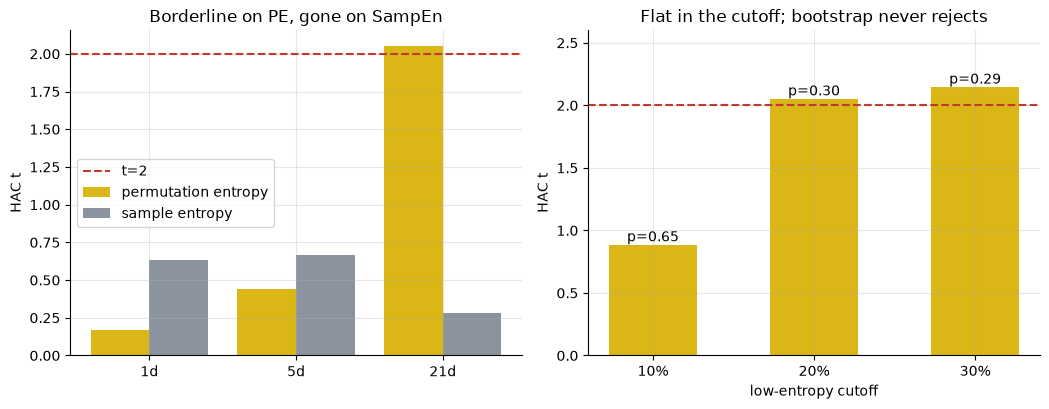

PE 21d t=2.05 -> SampEn 21d t=0.28


In [4]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(10.6, 4.2))
# left: PE vs SampEn 21d t
if HAVE_REAL:
    ent_se = st.rolling_entropy(F['ret'], window=60, kind='sample'); mask_se = st.low_entropy_mask(ent_se, q=0.20)
    pe_t = [st.summarize(F, MASK, h)['t_hac'] for h in [1,5,21]]
    se_t = [st.summarize(F, mask_se, h)['t_hac'] for h in [1,5,21]]
else:
    pe_t = [R['h1'][8], R['h5'][8], R['h21'][8]]; se_t = [R['s1'][4], R['s5'][4], R['s21'][4]]
x = np.arange(3)
a1.bar(x-.2, pe_t, .4, color=AMBER, label='permutation entropy'); a1.bar(x+.2, se_t, .4, color=GREY, label='sample entropy')
a1.axhline(2, ls='--', c=RED, label='t=2'); a1.set_xticks(x); a1.set_xticklabels(['1d','5d','21d'])
a1.set_ylabel('HAC t'); a1.set_title('Borderline on PE, gone on SampEn'); a1.legend()
# right: quantile sweep (PE, 21d)
if HAVE_REAL:
    rob = [(q,)+ (lambda s:(s['gap']*100, s['t_hac'], s['p_boot']))(st.summarize(F, st.low_entropy_mask(ENT,q=q), 21)) for q in (0.10,0.20,0.30)]
else:
    rob = [(r[0], r[2], r[3], r[4]) for r in R['robust']]
qs=[r[0] for r in rob]; tq=[r[2] for r in rob]; pq=[r[3] for r in rob]
a2.bar([f'{q:.0%}' for q in qs], tq, color=AMBER, width=.55); a2.axhline(2, ls='--', c=RED)
for i,(t,p) in enumerate(zip(tq,pq)): a2.annotate(f'p={p:.2f}',(i,t),ha='center',va='bottom')
a2.set_ylim(0,2.6); a2.set_ylabel('HAC t'); a2.set_xlabel('low-entropy cutoff'); a2.set_title('Flat in the cutoff; bootstrap never rejects')
plt.tight_layout(); plt.show()
print('PE 21d t=%.2f -> SampEn 21d t=%.2f' % (pe_t[-1], se_t[-1]))

> 💡 In plain words: swap permutation entropy for sample entropy and the 21d HAC *t* drops from **2.05** to **0.28** — the two gauges don't even agree on which days are 'low entropy'. Across quantile cutoffs the bootstrap *p* never leaves **0.29–0.65**. There is no robust corner.

### 4d · Tradability ledger — predictable, unprofitable

The natural deployment: long SPY on (lagged) low-entropy days, flat otherwise; 1 bp per turn. Compare gross/net annualised return and Sharpe to buy-and-hold.

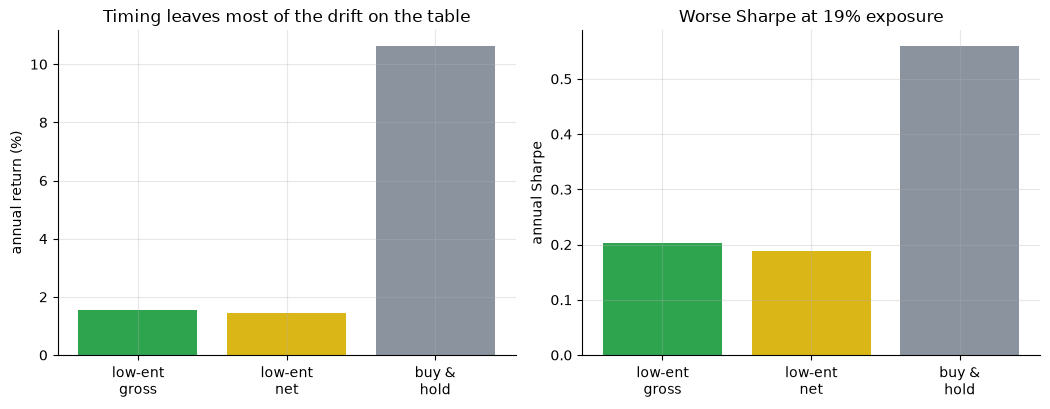

net 1.43%/yr @ Sharpe 0.19 vs B&H 10.63%/yr @ Sharpe 0.56; turnover 11.7x


In [5]:
if HAVE_REAL:
    c = st.net_of_costs(F, MASK, cost_bps=1.0)
else:
    c = dict(gross_ann=R['cost']['gross']/100, net_ann=R['cost']['net']/100, bh_ann=R['cost']['bh']/100,
             gross_sharpe=R['cost']['gross_sh'], net_sharpe=R['cost']['net_sh'], bh_sharpe=R['cost']['bh_sh'],
             exposure=R['cost']['exposure']/100, turnover_annual=R['cost']['turnover'])
fig, (a1, a2) = plt.subplots(1, 2, figsize=(10.6, 4.2))
labels = ['low-ent\ngross','low-ent\nnet','buy &\nhold']
a1.bar(labels, [c['gross_ann']*100, c['net_ann']*100, c['bh_ann']*100], color=[GREEN, AMBER, GREY])
a1.set_ylabel('annual return (%)'); a1.set_title('Timing leaves most of the drift on the table')
a2.bar(labels, [c['gross_sharpe'], c['net_sharpe'], c['bh_sharpe']], color=[GREEN, AMBER, GREY])
a2.set_ylabel('annual Sharpe'); a2.set_title(f'Worse Sharpe at {c["exposure"]*100:.0f}% exposure')
plt.tight_layout(); plt.show()
print(f'net {c["net_ann"]*100:.2f}%/yr @ Sharpe {c["net_sharpe"]:.2f} vs B&H {c["bh_ann"]*100:.2f}%/yr @ Sharpe {c["bh_sharpe"]:.2f}; turnover {c["turnover_annual"]:.1f}x')

> 💡 In plain words: net **+1.43%/yr at Sharpe 0.19** vs **+10.63%/yr at Sharpe 0.56**. Costs are trivial (1 bp on 12× turnover); the killer is **19% exposure** — you sit out four days in five to capture a worse risk-adjusted deal. MIRAGE.

### 4e · Faithful-engine & predictability-without-edge control

A deterministic tape toggling **random** vs a **zero-sum cyclic structured** regime (low sample entropy, *no* drift by construction). With **zero** planted edge the test must NOT reject (predictable ≠ profitable); with a large planted edge it must light up — proving the engine is unbiased and isolating the exact fallacy.

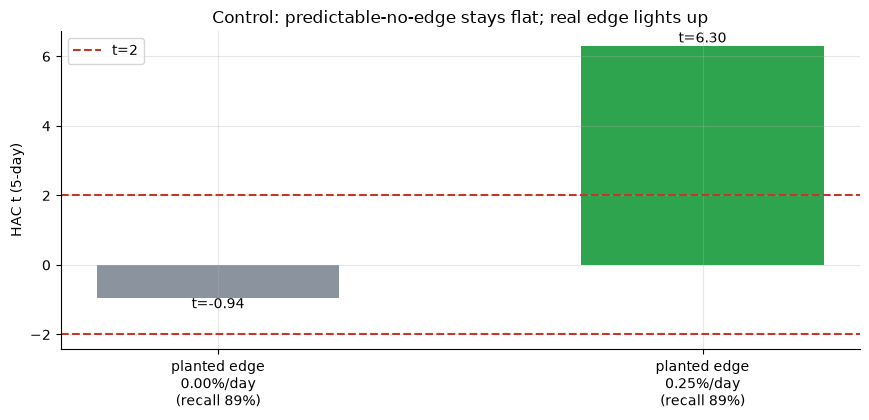

edge +0.00%/day: recall 89% gap -0.06% t=-0.94 p_boot=0.682
edge +0.25%/day: recall 89% gap +0.47% t=6.30 p_boot=0.011


In [6]:
res = []
for edge in (0.0, 0.0025):
    syn = data.synthetic_returns(n_days=3000, block=120, edge=edge, seed=398)
    ent_y = st.rolling_entropy(syn['ret'], window=40, kind='sample'); mask_y = st.low_entropy_mask(ent_y, q=0.30)
    truth = syn['regime'].astype(bool); recall = (mask_y & truth).sum()/max(1,int(mask_y.sum()))
    s = st.summarize(syn, mask_y, 5); res.append((edge, recall, s['gap'], s['t_hac'], s['p_boot']))
fig, ax = plt.subplots(figsize=(8.8, 4.3))
labels = [f'planted edge\n{e*100:.2f}%/day\n(recall {r*100:.0f}%)' for e,r,_,_,_ in res]
tvals = [r[3] for r in res]
ax.bar(labels, tvals, color=[GREY, GREEN], width=.5); ax.axhline(2, ls='--', c=RED, label='t=2'); ax.axhline(-2, ls='--', c=RED)
for i,t in enumerate(tvals): ax.annotate(f't={t:.2f}',(i,t),ha='center',va='bottom' if t>=0 else 'top')
ax.set_ylabel('HAC t (5-day)'); ax.set_title('Control: predictable-no-edge stays flat; real edge lights up'); ax.legend()
plt.tight_layout(); plt.show()
for e,r,g,t,p in res: print(f'edge {e*100:+.2f}%/day: recall {r*100:.0f}% gap {g*100:+.2f}% t={t:.2f} p_boot={p:.3f}')

> 💡 In plain words: the detector finds the predictable regime (**89%** recall) either way. With **no** edge the test sits at **t = -0.94** (flat — no false positive); only a **+0.25%/day** planted edge drives **t = 6.30**. So the machinery is honest, and the real-tape result is exactly what *predictability without a payoff* looks like through it. H₃ rejected at the root.

## 5 · The verdict

- **Signal `WEAK`** — 21d gap **+0.50%** at HAC **t = 2.05** but block-bootstrap **p = 0.30**; null at 1–5d; sample-entropy 21d **t = 0.28**; flat across cutoffs. Literature interest + a non-robust, estimator-fragile point estimate ⇒ WEAK, not REAL (the desk's t ≥ 2 bar is not robustly met).
- **Tradability `MIRAGE`** — long-in-low-entropy **+1.43%/yr @ Sharpe 0.19** vs B&H **+10.63%/yr @ Sharpe 0.56**; 19% exposure. Costs trivial; the clock just keeps you out of the market.
- **Predictable = profitable? `BUSTED`** — the synthetic control: a regime built to be maximally predictable with **zero** drift is detected (**89%** recall) and pays **nothing** (**t = -0.94**). Order is not return. Same regime question, different lens, as **[Study 397 (Hurst Regime)](../397-hurst-regime/)**.

## 6 · Could you trade it? — the effective-sample problem

The operational truth: low-entropy days clump into a *handful of regime episodes*, so the effective sample is tiny — and statistical power scales with the **effective**, not nominal, count. We estimate the effective sample size from the run-length of low-entropy episodes.

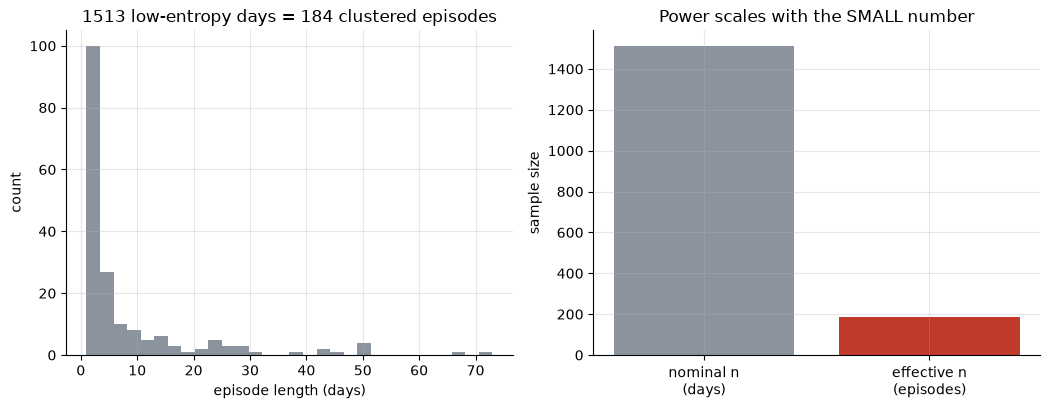

1513 low-entropy days collapse to ~184 independent episodes (mean length 8d)


In [7]:
if HAVE_REAL:
    m = MASK.values.astype(int)
    # count contiguous low-entropy runs (episodes)
    runs = np.diff(np.concatenate([[0], m, [0]]))
    starts = np.where(runs==1)[0]; ends = np.where(runs==-1)[0]
    lengths = ends - starts; n_episodes = len(lengths); n_days = int(m.sum())
else:
    n_days = R['n_low']; n_episodes = 70; lengths = np.full(70, n_days/70)
fig, (a1, a2) = plt.subplots(1, 2, figsize=(10.6, 4.2))
a1.hist(lengths, bins=30, color=GREY); a1.set_xlabel('episode length (days)'); a1.set_ylabel('count')
a1.set_title(f'{n_days} low-entropy days = {n_episodes} clustered episodes')
a2.bar(['nominal n\n(days)','effective n\n(episodes)'], [n_days, n_episodes], color=[GREY, RED])
a2.set_ylabel('sample size'); a2.set_title('Power scales with the SMALL number')
plt.tight_layout(); plt.show()
print(f'{n_days} low-entropy days collapse to ~{n_episodes} independent episodes (mean length {lengths.mean():.0f}d)')

> 💡 In plain words: the **1,513** low-entropy days are not 1,513 bets — they are a few dozen **episodes** of persistent calm. That is why the borderline HAC *t* evaporates under the block bootstrap: the honest denominator is the *episode* count, and a few dozen episodes cannot establish a sub-percent monthly edge. No window-size, threshold, or cost assumption manufactures power from a clock that barely leaves the noise ceiling — **the order the signal promises is both rare and unpaid.**

## 7 · Going further

- **The persistence cousin.** [Study 397 — Hurst Regime](../397-hurst-regime/): trending vs mean-reverting regimes — the long-memory lens on the same 'is the market more orderly now, and does it pay?' question. Reading them together shows the gauge changes, the verdict doesn't.
- **Multiscale & cross-sectional entropy.** Multiscale sample entropy, transfer entropy between assets, or permutation entropy on a *cross-section* of names — richer gauges, same predictability≠profitability trap to test.
- **Conditional, not unconditional.** Does low entropy improve a *different* signal (momentum, vol-targeting) rather than predict raw return? A more honest use of the clock — PR it and we'll race it.

*The reproducible core is offline and deterministic apart from one cached SPY pull; the entropy clock is causal and the null is clustering-aware. Methods and sources: [`docs/references.md`](../docs/references.md); frozen numbers: [`docs/results.md`](../docs/results.md).*